# SmartStock AI: Exploratory Data Analysis

This notebook will inspect the raw M5 files, data quality, demand distributions, and time-based patterns. No analysis is included in the initial scaffold.

## Imports Libraries

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



## Import Datasets

In [2]:
import sys
from pathlib import Path

# Ensure the project root is on PYTHONPATH so `src` can be imported
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import RAW_DATA_DIR

calendar_data = pd.read_csv(RAW_DATA_DIR / "calendar.csv")
sales_data = pd.read_csv(RAW_DATA_DIR / "sales_train_evaluation.csv")
sell_price_data = pd.read_csv(RAW_DATA_DIR / "sell_prices.csv")



### shape

In [3]:
print(calendar_data.shape)
print(sales_data.shape)
print(sell_price_data.shape)

(1969, 14)
(30490, 1947)
(6841121, 4)


### colomns


In [4]:
print(calendar_data.columns)
print(sales_data.columns)
print(sell_price_data.columns)

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='str')
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
       'd_1939', 'd_1940', 'd_1941'],
      dtype='str', length=1947)
Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='str')


### Data types

In [5]:
print(calendar_data.info())
print(sales_data.info())
print(sell_price_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 454.7 MB
None
<class 'pandas.DataFrame'>
RangeIndex:

### Total memory in MB

In [6]:
print(calendar_data.memory_usage(deep=True).sum() / (1024 ** 2))
print(sales_data.memory_usage(deep=True).sum() / (1024 ** 2))
print(sell_price_data.memory_usage(deep=True).sum() / (1024 ** 2))

0.2569284439086914
454.7429389953613
318.14798069000244


### First few rows

In [7]:
print(sales_data.head(5))
print(sell_price_data.head(5))
print(calendar_data.head(5))


                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  d_1935  d_1936  \
0       CA    0    0    0    0  ...       2       4       0       0       0   
1       CA    0    0    0    0  ...       0       1       2       1       1   
2       CA    0    0    0    0  ...       1       0       2       0       0   
3       CA    0    0    0    0  ...       1       1       0       4       0   
4       CA    0    0    0    0  ...       0       0       0       2       1   

   d_1937  d_1938  d_1939  d_1940  d_1941  


### Last Few Rows

In [8]:
print(sales_data.tail(5))
print(sell_price_data.tail(5))
print(calendar_data.tail(5))

                                id      item_id  dept_id cat_id store_id  \
30485  FOODS_3_823_WI_3_evaluation  FOODS_3_823  FOODS_3  FOODS     WI_3   
30486  FOODS_3_824_WI_3_evaluation  FOODS_3_824  FOODS_3  FOODS     WI_3   
30487  FOODS_3_825_WI_3_evaluation  FOODS_3_825  FOODS_3  FOODS     WI_3   
30488  FOODS_3_826_WI_3_evaluation  FOODS_3_826  FOODS_3  FOODS     WI_3   
30489  FOODS_3_827_WI_3_evaluation  FOODS_3_827  FOODS_3  FOODS     WI_3   

      state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  d_1935  \
30485       WI    0    0    2    2  ...       1       0       3       0   
30486       WI    0    0    0    0  ...       0       0       0       0   
30487       WI    0    6    0    2  ...       0       0       1       2   
30488       WI    0    0    0    0  ...       1       1       1       4   
30489       WI    0    0    0    0  ...       1       2       0       5   

       d_1936  d_1937  d_1938  d_1939  d_1940  d_1941  
30485       1       1       0       

### No of coloumns

In [9]:
print(len(sales_data.columns))
print(len(sell_price_data.columns))
print(len(calendar_data.columns))

1947
4
14


### Understand the sales dataset

In [10]:
print("Unique items:", sales_data["item_id"].nunique())
print("Departments:", sales_data["dept_id"].nunique())
print("Categories:", sales_data["cat_id"].nunique())
print("Stores:", sales_data["store_id"].nunique())
print("States:", sales_data["state_id"].nunique())

Unique items: 3049
Departments: 7
Categories: 3
Stores: 10
States: 3


### Check the Calander Dataset

In [11]:
print("Start date:", calendar_data["date"].min())
print("End date:", calendar_data["date"].max())
print("Number of dates:", calendar_data["date"].nunique())

calendar_data[["date", "d", "wm_yr_wk", "weekday", "month", "year"]].head()

Start date: 2011-01-29
End date: 2016-06-19
Number of dates: 1969


,date,d,wm_yr_wk,weekday,month,year
0,2011-01-29,d_1,11101,Saturday,1,2011
1,2011-01-30,d_2,11101,Sunday,1,2011
2,2011-01-31,d_3,11101,Monday,1,2011
3,2011-02-01,d_4,11101,Tuesday,2,2011
4,2011-02-02,d_5,11101,Wednesday,2,2011


### daily sales columns

In [12]:
day_cols = [
    col for col in sales_data.columns
    if col.startswith("d_")
]

print("Number of sales days:", len(day_cols))
print("First:", day_cols[:5])
print("Last:", day_cols[-5:])

Number of sales days: 1941
First: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last: ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']


### Memory warning before long transformation

In [13]:
number_of_series = len(sales_data)
number_of_days = len(day_cols)

estimated_rows = number_of_series * number_of_days

print(f"Series: {number_of_series:,}")
print(f"Days: {number_of_days:,}")
print(f"Estimated long rows: {estimated_rows:,}")

Series: 30,490
Days: 1,941
Estimated long rows: 59,181,090


Full wide-to-long transformation would create approximately 59 million records, so development should initially use a controlled subset.

### Sales distribution

In [14]:
sales_values = sales_data[day_cols].to_numpy()

print("Mean:", sales_values.mean())
print("Median:", np.median(sales_values))
print("Std:", sales_values.std())
print("Min:", sales_values.min())
print("Max:", sales_values.max())

print("75th percentile:", np.percentile(sales_values, 75))
print("90th percentile:", np.percentile(sales_values, 90))
print("95th percentile:", np.percentile(sales_values, 95))
print("99th percentile:", np.percentile(sales_values, 99))

Mean: 1.1308878055473464
Median: 0.0
Std: 3.8700380872055162
Min: 0
Max: 763
75th percentile: 1.0
90th percentile: 3.0
95th percentile: 5.0
99th percentile: 15.0


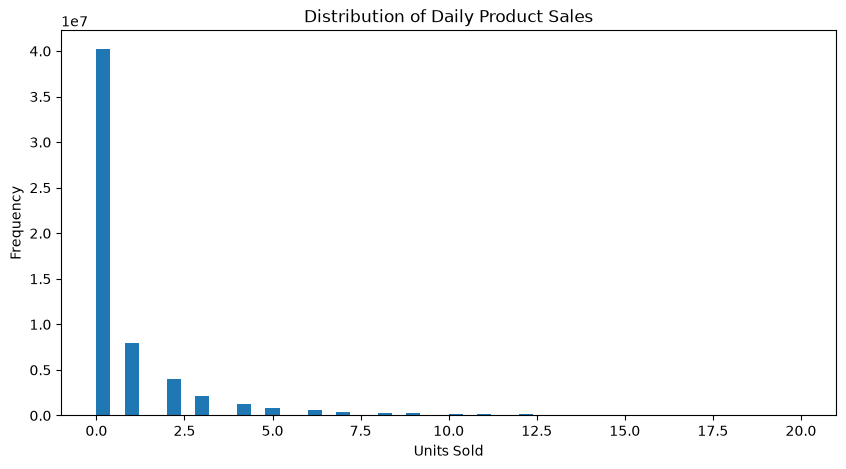

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    sales_values.flatten(),
    bins=50,
    range=(0, 20)
)

plt.title("Distribution of Daily Product Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

### Zero-demand analysis

Zero-demand percentage: 68.00%


,category,zero_percentage
0,FOODS,61.773422
1,HOBBIES,77.149166
2,HOUSEHOLD,71.602198


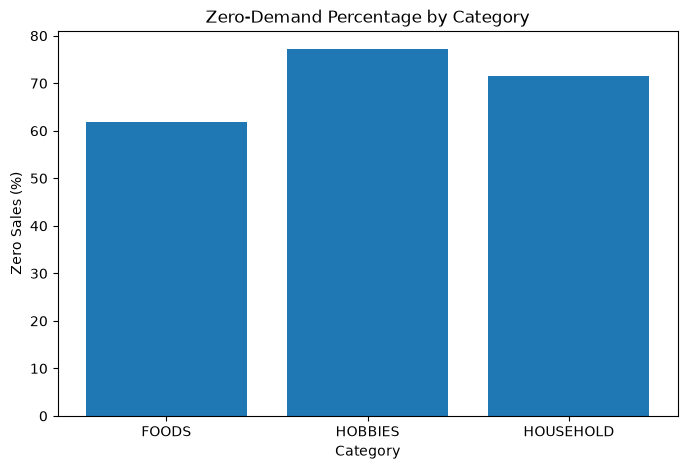

In [16]:
total_values = sales_values.size
zero_values = (sales_values == 0).sum()

zero_percentage = zero_values / total_values * 100

print(f"Zero-demand percentage: {zero_percentage:.2f}%")

category_zero_analysis = []

for category, group in sales_data.groupby("cat_id"):

    values = group[day_cols].to_numpy()

    zero_pct = (values == 0).sum() / values.size * 100

    category_zero_analysis.append({
        "category": category,
        "zero_percentage": zero_pct
    })

category_zero_df = pd.DataFrame(category_zero_analysis)

display(category_zero_df)

plt.figure(figsize=(8, 5))

plt.bar(
    category_zero_df["category"],
    category_zero_df["zero_percentage"]
)

plt.title("Zero-Demand Percentage by Category")
plt.ylabel("Zero Sales (%)")
plt.xlabel("Category")

plt.show()

### Total demand by category

cat_id
FOODS        45922427
HOUSEHOLD    14764090
HOBBIES       6240656
dtype: int64

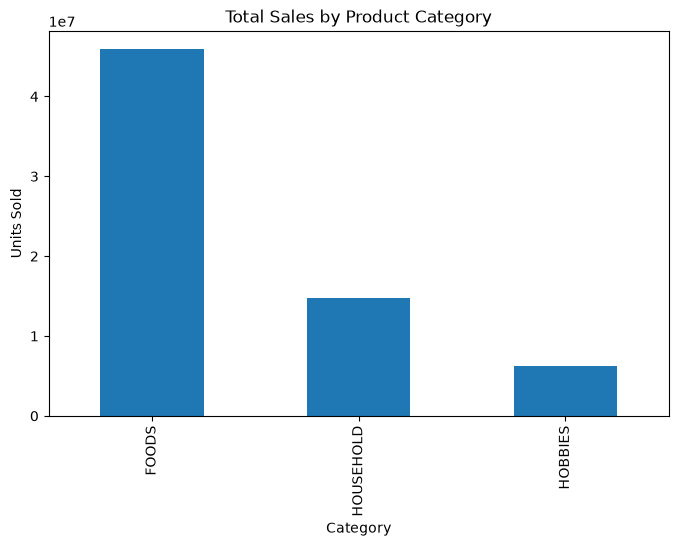

In [17]:
category_sales = (
    sales_data
    .groupby("cat_id")[day_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

display(category_sales)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.show()

### Demand by store

store_id
CA_3    11363540
CA_1     7832248
TX_2     7329642
WI_2     6697988
WI_3     6542557
TX_3     6205940
CA_2     5818395
TX_1     5692823
WI_1     5261506
CA_4     4182534
dtype: int64

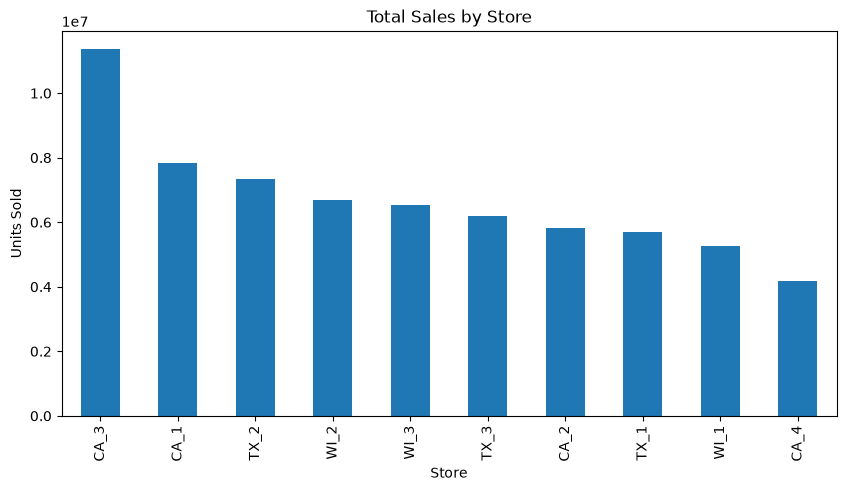

In [18]:
store_sales = (
    sales_data
    .groupby("store_id")[day_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

display(store_sales)

plt.figure(figsize=(10, 5))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")

plt.show()

### Create total sales per day

In [19]:
daily_total_sales = sales_data[day_cols].sum(axis=0)

daily_total_df = pd.DataFrame({
    "d": daily_total_sales.index,
    "sales": daily_total_sales.values
})

daily_total_df = daily_total_df.merge(
    calendar_data[[
        "d",
        "date",
        "weekday",
        "month",
        "year",
        "event_name_1",
        "event_type_1"
    ]],
    on="d",
    how="left"
)

display(daily_total_df.head())

,d,sales,date,weekday,month,year,event_name_1,event_type_1
0,d_1,32631,2011-01-29,Saturday,1,2011,NaN,NaN
1,d_2,31749,2011-01-30,Sunday,1,2011,NaN,NaN
2,d_3,23783,2011-01-31,Monday,1,2011,NaN,NaN
3,d_4,25412,2011-02-01,Tuesday,2,2011,NaN,NaN
4,d_5,19146,2011-02-02,Wednesday,2,2011,NaN,NaN


### Plot total sales over time

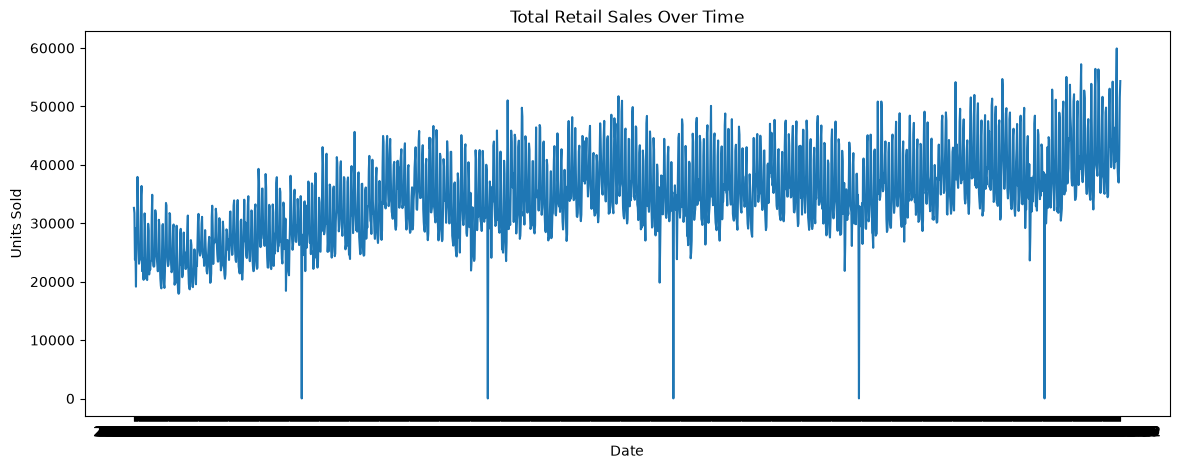

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_total_df["date"],
    daily_total_df["sales"]
)

plt.title("Total Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

### Demand by weekday

weekday
Friday       34357.472924
Monday       32994.931408
Saturday     41706.269784
Sunday       41304.050360
Thursday     30321.039711
Tuesday      30500.483755
Wednesday    30130.418773
Name: sales, dtype: float64

weekday
Monday       32994.931408
Tuesday      30500.483755
Wednesday    30130.418773
Thursday     30321.039711
Friday       34357.472924
Saturday     41706.269784
Sunday       41304.050360
Name: sales, dtype: float64

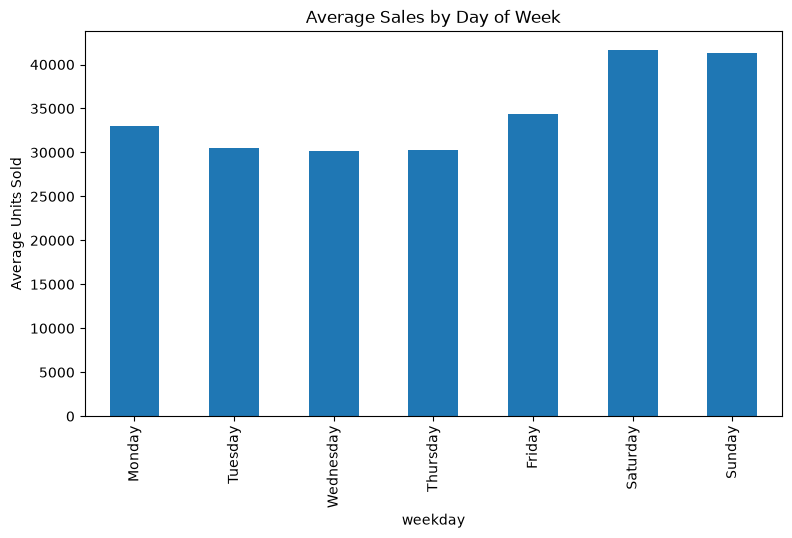

In [21]:
weekday_sales = (
    daily_total_df
    .groupby("weekday")["sales"]
    .mean()
)

display(weekday_sales)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

display(weekday_sales)

plt.figure(figsize=(9, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.ylabel("Average Units Sold")

plt.show()

### Weekend vs weekday

In [22]:
daily_total_df["is_weekend"] = (
    daily_total_df["weekday"]
    .isin(["Saturday", "Sunday"])
)

weekend_analysis = (
    daily_total_df
    .groupby("is_weekend")["sales"]
    .mean()
)

display(weekend_analysis)

is_weekend
False    31660.869314
True     41505.160072
Name: sales, dtype: float64

### Demand by month

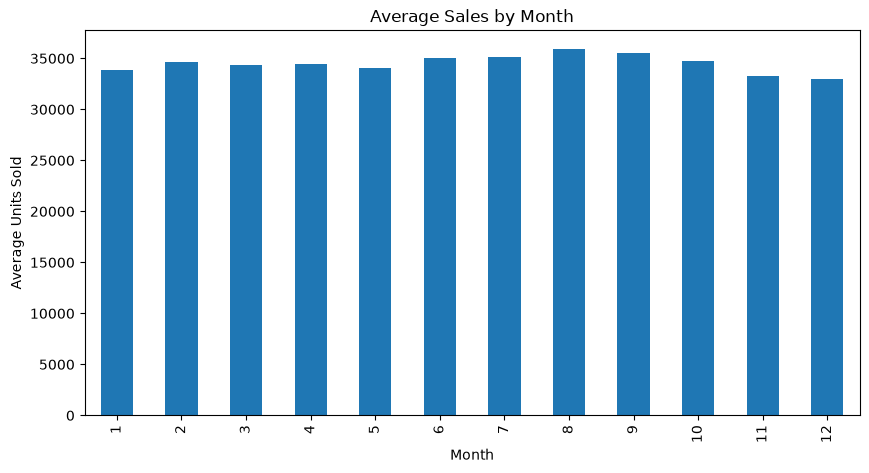

In [23]:
monthly_sales = (
    daily_total_df
    .groupby("month")["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.show()

### Eventday analysis

In [24]:
daily_total_df["is_event"] = (
    daily_total_df["event_name_1"].notna()
)

event_sales = (
    daily_total_df
    .groupby("is_event")["sales"]
    .mean()
)

display(event_sales)

event_type_sales = (
    daily_total_df
    .dropna(subset=["event_type_1"])
    .groupby("event_type_1")["sales"]
    .mean()
    .sort_values(ascending=False)
)

display(event_type_sales)

is_event
False    34609.336511
True     33029.911392
Name: sales, dtype: float64

event_type_1
Sporting     35796.062500
Cultural     34718.594595
Religious    34426.240741
National     29458.509804
Name: sales, dtype: float64

Average demand differs between event and non-event days, suggesting event information may contain predictive value.

### Price distribution

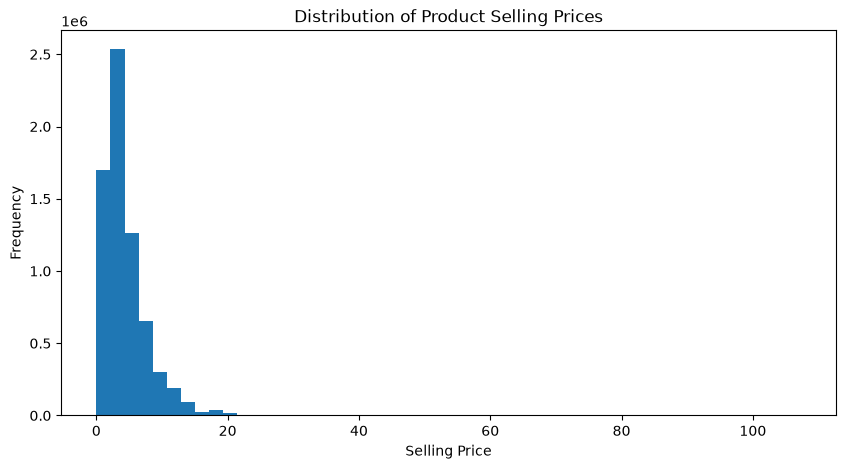

In [25]:
sell_price_data["sell_price"].describe()

sell_price_data["sell_price"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

plt.figure(figsize=(10, 5))

plt.hist(
    sell_price_data["sell_price"],
    bins=50
)

plt.title("Distribution of Product Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

### Check whether prices change

In [26]:
price_change_counts = (
    sell_price_data
    .groupby(["store_id", "item_id"])["sell_price"]
    .nunique()
)

print(
    "Product-store combinations with price changes:",
    (price_change_counts > 1).sum()
)

print(
    "Total product-store combinations:",
    len(price_change_counts)
)

percentage = (
    (price_change_counts > 1).mean() * 100
)

print(f"{percentage:.2f}% have price changes")

Product-store combinations with price changes: 22243
Total product-store combinations: 30490
72.95% have price changes


sell_price,
price_change need to get thge modeling

### Plot price history for one product

,store_id,item_id,wm_yr_wk,sell_price
368746,CA_1,FOODS_1_001,11101,2.0
368747,CA_1,FOODS_1_001,11102,2.0
368748,CA_1,FOODS_1_001,11103,2.0
368749,CA_1,FOODS_1_001,11104,2.0
368750,CA_1,FOODS_1_001,11105,2.0


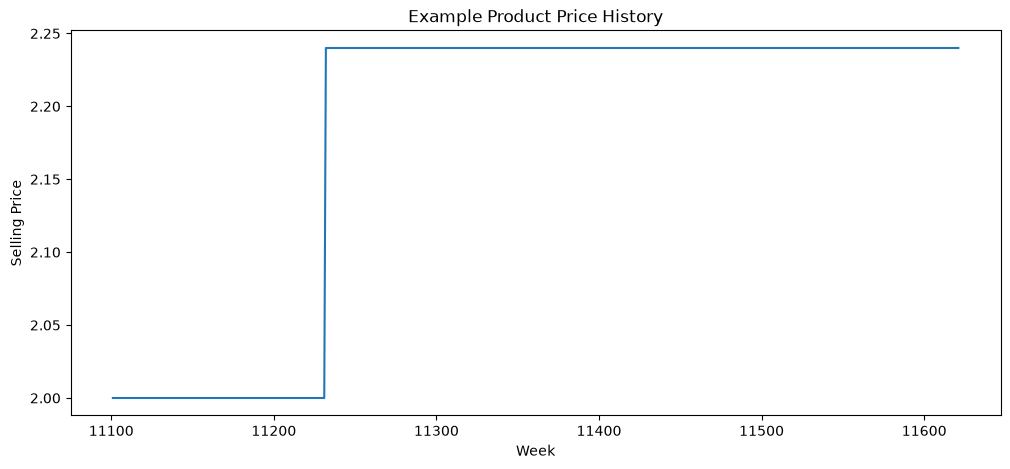

In [27]:
example_prices = sell_price_data[
    (sell_price_data["store_id"] == "CA_1") &
    (sell_price_data["item_id"] == "FOODS_1_001")
].copy()

display(example_prices.head())

plt.figure(figsize=(12, 5))

plt.plot(
    example_prices["wm_yr_wk"],
    example_prices["sell_price"]
)

plt.title("Example Product Price History")
plt.xlabel("Week")
plt.ylabel("Selling Price")

plt.show()

### Plot individual product demand

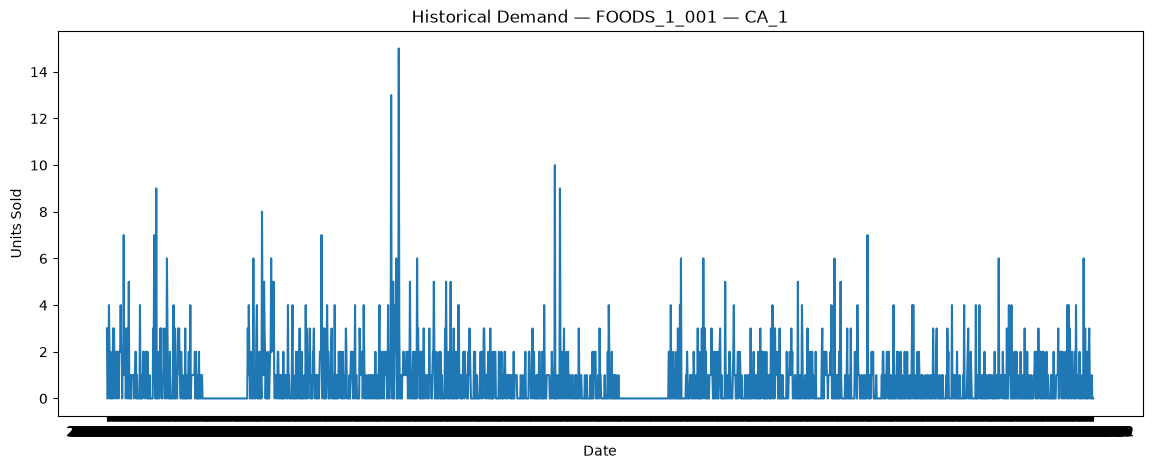

In [28]:
example_row = sales_data[
    (sales_data["item_id"] == "FOODS_1_001") &
    (sales_data["store_id"] == "CA_1")
].iloc[0]

product_sales = pd.DataFrame({
    "d": day_cols,
    "sales": example_row[day_cols].to_numpy()
})

product_sales = product_sales.merge(
    calendar_data[["d", "date"]],
    on="d",
    how="left"
)

plt.figure(figsize=(14, 5))

plt.plot(
    product_sales["date"],
    product_sales["sales"]
)

plt.title("Historical Demand — FOODS_1_001 — CA_1")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

## Key Findings and Modeling Implications

Finding	and Modeling implication


1.Demand contains many zero-sales observations:	Use retail-appropriate regression metrics such as MAE/WAPE

2.Demand differs by weekday:	Include weekday/weekend features

3.Products have very different demand levels:	Include item embeddings

4.Stores have different demand patterns:	Include store embeddings

5.Categories differ significantly:	Include category information

6.Product prices vary over time:	Include current price and price change features

7.Recent demand shows temporal patterns:	Create lag features

8.Demand varies over longer windows:	Create rolling averages

9.Events coincide with demand changes:	Include event/calendar features
